# TPC‑H + PrivateSQL (Customer policy) — Notebook Overview

This notebook evaluates PrivateSQL-style differential privacy on TPC‑H queries using a "customer" privacy policy. It loads TPC‑H tables, builds DP queries, runs many DP trials, computes error metrics, and plots results.

In [1]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
os.environ["SPARK_HOME"] = "/Users/kinchintong/project/tumult-labs/spark-4.0.1-bin-hadoop3"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import findspark
findspark.init(os.environ["SPARK_HOME"])
from math import floor
from pyspark import SparkFiles
from pyspark.sql import SparkSession, types as T, functions as F
from tmlt.analytics.privacy_budget import PureDPBudget
from tmlt.analytics.protected_change import (AddOneRow, AddMaxRows, AddRowsWithID)
from tmlt.analytics.query_builder import QueryBuilder
from tmlt.analytics.session import Session, ColumnType
from tmlt.analytics.keyset import KeySet
from functools import reduce
from tmlt.analytics import (
    AddOneRow,
    PureDPBudget,
    QueryBuilder,
    Session,
    AddRowsWithID,
    GroupbyCountQuery,
)

from tmlt.analytics.truncation_strategy import TruncationStrategy

# Silence some Spark warnings
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', ResourceWarning)

findspark.init()

# Set up Spark
spark = (
    SparkSession.builder
    .appName("tpch-setup")
    .master("local[*]")           # drop if connecting to a cluster
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.driver.memory", "16g")
    .config("spark.executor.memory", "16g")
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)
print("Spark version:", spark.version)

spark.sparkContext.setLogLevel("ERROR")

spark.conf.set("spark.sql.session.timeZone", "UTC")

# CREATE EMPTY TABLES (schema only) ----
def create_empty_tables():
    for t in TABLES:
        empty = spark.createDataFrame([], SCHEMAS[t])
        # managed Parquet tables; change to .format("delta") if using Delta
        #empty.write.mode("overwrite").format("parquet").saveAsTable(t)
    print(f"Created empty schema in database `{DB}`.")

# LOAD FROM CSV / .tbl (pipe-delimited with trailing '|') ----
def load_from_csv(src_dir: str):
    for t in TABLES:
        schema = SCHEMAS[t]
        path = f"{src_dir}/{t}.tbl"   # change to .csv if needed
        #only if the path exists
        if not os.path.exists(path):
            print(f"Path does not exist: {path}")
            continue
        
        print(f"Loading {t} from {path}...")

        # create a temporary wide schema of string columns (named) to absorb trailing '|'
        n_cols = len(schema.fields) + 1
        tmp_fields = [T.StructField(f"_c{i}", T.StringType(), True) for i in range(n_cols)]
        tmp_schema = T.StructType(tmp_fields)
        #print("tmp_schema:", tmp_schema)
        df_raw = (spark.read
                  .option("sep", "|")
                  .option("header", "false")
                  .option("mode", "PERMISSIVE")
                  .schema(tmp_schema)  # read wide to absorb trailing '|'
                  .csv(path))
        #print(f"Raw schema for {t}:")
        #df_raw.printSchema()
        
        # keep only first N columns and cast to target schema
        cols = df_raw.columns[:len(schema.fields)]
        df = df_raw.select([F.col(c).alias(schema.fields[i].name) for i, c in enumerate(cols)])
        # cast columns to target types
        for f in schema.fields:
            if isinstance(f.dataType, T.DateType):
                df = df.withColumn(f.name, F.to_date(F.col(f.name), "yyyy-MM-dd"))
            elif isinstance(f.dataType, T.DecimalType):
                df = df.withColumn(f.name, F.col(f.name).cast(f.dataType))
            elif isinstance(f.dataType, T.IntegerType):
                df = df.withColumn(f.name, F.col(f.name).cast("int"))
            # strings need no cast
        df.write.mode("overwrite").format("parquet").saveAsTable(t)
        print(f"Loaded {t} from {path}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/09 00:01:45 WARN Utils: Your hostname, kinchins-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.184 instead (on interface en0)
26/01/09 00:01:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/09 00:01:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/09 00:01:45 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/01/09 00:01:45 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Spark version: 4.0.1


In [2]:
DB = "tpch"                          # change as you like
OUTPUT="customer_policy_session_1_eps_results"  # output directory for results

# Define canonical TPC-H schemas ----
dec = lambda p, s: T.DecimalType(p, s)
SCHEMAS = {
    "region":   T.StructType([
        T.StructField("r_regionkey", T.IntegerType(), False),
        T.StructField("r_name",      T.StringType(),  False),
        T.StructField("r_comment",   T.StringType(),  True),
    ]),
    "nation":   T.StructType([
        T.StructField("n_nationkey", T.IntegerType(), False),
        T.StructField("n_name",      T.StringType(),  False),
        T.StructField("n_regionkey", T.IntegerType(), False),
        T.StructField("n_comment",   T.StringType(),  True),
    ]),
    "part":     T.StructType([
        T.StructField("p_partkey",     T.IntegerType(), False),
        T.StructField("p_name",        T.StringType(),  False),
        T.StructField("p_mfgr",        T.StringType(),  False),
        T.StructField("p_brand",       T.StringType(),  False),
        T.StructField("p_type",        T.StringType(),  False),
        T.StructField("p_size",        T.IntegerType(), False),
        T.StructField("p_container",   T.StringType(),  False),
        T.StructField("p_retailprice", T.FloatType(),   False),
        T.StructField("p_comment",     T.StringType(),  True),
    ]),
    "supplier": T.StructType([
        T.StructField("s_suppkey",   T.IntegerType(), False),
        T.StructField("s_name",      T.StringType(),  False),
        T.StructField("s_address",   T.StringType(),  False),
        T.StructField("s_nationkey", T.IntegerType(), False),
        T.StructField("s_phone",     T.StringType(),  False),
        T.StructField("s_acctbal",   T.FloatType(),   False),
        T.StructField("s_comment",   T.StringType(),  True),
    ]),
    "partsupp": T.StructType([
        T.StructField("ps_partkey",    T.IntegerType(), False),
        T.StructField("ps_suppkey",    T.IntegerType(), False),
        T.StructField("ps_availqty",   T.IntegerType(), False),
        T.StructField("ps_supplycost", T.FloatType(),   False),
        T.StructField("ps_comment",    T.StringType(),  True),
    ]),
    "customer": T.StructType([
        T.StructField("c_custkey",   T.IntegerType(), False),
        T.StructField("c_name",      T.StringType(),  False),
        T.StructField("c_address",   T.StringType(),  False),
        T.StructField("c_nationkey", T.IntegerType(), False),
        T.StructField("c_phone",     T.StringType(),  False),
        T.StructField("c_acctbal",   T.FloatType(),   False),
        T.StructField("c_mktsegment",T.StringType(),  True),
        T.StructField("c_comment",   T.StringType(),  True),
    ]),
    "orders":   T.StructType([
        T.StructField("o_orderkey",     T.IntegerType(), False),
        T.StructField("o_custkey",      T.IntegerType(), False),
        T.StructField("o_orderstatus",  T.StringType(),  False),
        T.StructField("o_totalprice",   T.FloatType(),   False),
        T.StructField("o_orderdate",    T.DateType(),    False),
        T.StructField("o_orderpriority",T.StringType(),  False),
        T.StructField("o_clerk",        T.StringType(),  False),
        T.StructField("o_shippriority", T.IntegerType(), False),
        T.StructField("o_comment",      T.StringType(),  True),
    ]),
    "lineitem": T.StructType([
        T.StructField("l_orderkey",      T.IntegerType(), False),
        T.StructField("l_partkey",       T.IntegerType(), False),
        T.StructField("l_suppkey",       T.IntegerType(), False),
        T.StructField("l_linenumber",    T.IntegerType(), False),
        T.StructField("l_quantity",      T.FloatType(),   False),
        T.StructField("l_extendedprice", T.FloatType(),   False),
        T.StructField("l_discount",      T.FloatType(),   False),
        T.StructField("l_tax",           T.FloatType(),   False),
        T.StructField("l_returnflag",    T.StringType(),  False),
        T.StructField("l_linestatus",    T.StringType(),  False),
        T.StructField("l_shipdate",      T.DateType(),    False),
        T.StructField("l_commitdate",    T.DateType(),    False),
        T.StructField("l_receiptdate",   T.DateType(),    False),
        T.StructField("l_shipinstruct",  T.StringType(),  False),
        T.StructField("l_shipmode",      T.StringType(),  False),
        T.StructField("l_comment",       T.StringType(),  True),
    ]),
}
TABLES = ["region","nation","part","supplier","partsupp","customer","orders","lineitem"]
spark.sql(f"CREATE DATABASE IF NOT EXISTS {DB}")
spark.catalog.setCurrentDatabase(DB)

create_empty_tables()


Created empty schema in database `tpch`.


In [3]:
SRC_CSV_DIR = "./raw"    # where *.tbl live
load_from_csv(SRC_CSV_DIR)

# Quick smoke test:
spark.sql("SHOW TABLES").show(truncate=False)
# show record count for each table
for t in TABLES:
    print(f"Table {t} has {spark.sql(f'SELECT count(*) FROM {t}').collect()[0][0]} records.")

Loading region from ./raw/region.tbl...
Loaded region from ./raw/region.tbl
Loading nation from ./raw/nation.tbl...
Loaded nation from ./raw/nation.tbl
Loading part from ./raw/part.tbl...


Loaded part from ./raw/part.tbl
Loading supplier from ./raw/supplier.tbl...
Loaded supplier from ./raw/supplier.tbl
Loading partsupp from ./raw/partsupp.tbl...
Loaded partsupp from ./raw/partsupp.tbl
Loading customer from ./raw/customer.tbl...
Loaded customer from ./raw/customer.tbl
Loading orders from ./raw/orders.tbl...


Loaded orders from ./raw/orders.tbl
Loading lineitem from ./raw/lineitem.tbl...


Loaded lineitem from ./raw/lineitem.tbl
+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
|tpch     |customer |false      |
|tpch     |lineitem |false      |
|tpch     |nation   |false      |
|tpch     |orders   |false      |
|tpch     |part     |false      |
|tpch     |partsupp |false      |
|tpch     |region   |false      |
|tpch     |supplier |false      |
+---------+---------+-----------+

Table region has 5 records.
Table nation has 25 records.
Table part has 200000 records.
Table supplier has 10000 records.
Table partsupp has 800000 records.
Table customer has 150000 records.
Table orders has 1500000 records.
Table lineitem has 6001215 records.


In [4]:
from pyspark.sql import SparkSession, DataFrame
import pyspark.sql.functions as F


def max_group_count(
    spark: SparkSession,
    table: str,
    key_col: str,
    where: str | None = None,
) -> tuple[str, int]:
    """
    Run the Spark SQL equivalent of:

        SELECT COUNT(key) AS count
        FROM table
        [WHERE ...]
        GROUP BY key
        ORDER BY count DESC
        LIMIT 1

    Returns: (key_value_as_string, count_as_int)
    """
    where_clause = f" WHERE {where} " if where else ""
    query = f"""
        SELECT {key_col} AS key, COUNT({key_col}) AS count
        FROM {table}
        {where_clause}
        GROUP BY {key_col}
        ORDER BY count DESC
        LIMIT 1
    """
    row = spark.sql(query).collect()
    if not row:
        raise ValueError("Query returned no rows (empty table or all rows filtered out).")

    print("Table:", table, ", key_col:", key_col, ", max count:", row[0]["count"])

    # row[0] has columns: key, count
    return str(row[0]["key"]), int(row[0]["count"])


max_group_count(spark, table="orders", key_col="o_custkey")
max_group_count(spark, table="lineitem", key_col="l_orderkey")
max_group_count(spark, table="lineitem", key_col="l_partkey")
max_group_count(spark, table="lineitem", key_col="l_suppkey")
max_group_count(spark, table="customer",key_col="c_nationkey")
max_group_count(spark, table="supplier",key_col="s_nationkey")
max_group_count(spark, table="partsupp",key_col="ps_partkey")
max_group_count(spark, table="partsupp",key_col="ps_suppkey")
max_group_count(spark, table="nation",key_col="n_regionkey")



Table: orders , key_col: o_custkey , max count: 41
Table: lineitem , key_col: l_orderkey , max count: 7
Table: lineitem , key_col: l_partkey , max count: 57
Table: lineitem , key_col: l_suppkey , max count: 694
Table: customer , key_col: c_nationkey , max count: 6161
Table: supplier , key_col: s_nationkey , max count: 438
Table: partsupp , key_col: ps_partkey , max count: 4
Table: partsupp , key_col: ps_suppkey , max count: 80
Table: nation , key_col: n_regionkey , max count: 5


('1', 5)

In [5]:
#\max_{c} \; |\{\, \text{lineitem rows belonging to customer } c \,\}|
def get_lineitem_mf():
    query = f"""
    SELECT COUNT(*) AS cnt
    FROM lineitem l
    JOIN orders o ON l.l_orderkey = o.o_orderkey
    GROUP BY o.o_custkey
    ORDER BY cnt DESC
    LIMIT 1;
        """
    row = spark.sql(query).collect()
    if not row:
        raise ValueError("Query returned no rows (empty table or all rows filtered out).")

    return row[0]["cnt"]

In [6]:
lineitem_mf = get_lineitem_mf()
print("Lineitem max frequency (mf) per customer:", lineitem_mf)

orders_mf = max_group_count(spark, table="orders", key_col="o_custkey")[1]
print("Orders max frequency (mf) per customer:", orders_mf)


Lineitem max frequency (mf) per customer: 178
Table: orders , key_col: o_custkey , max count: 41
Orders max frequency (mf) per customer: 41


***
## TPC-H Queries Evaluated

- **Q1 - Pricing Summary Report Query**<br>
    This query reports the amount of business that was billed, shipped, and returned.

- **Q4 - Order Priority Checking Query**<br>
    This query determines how well the order priority system is working and gives an assessment of customer satisfac-
tion.

- **Q13 - Customer Distribution Query**<br>
    This query seeks relationships between customers and the size of their orders.

- **Q16 - Parts/Supplier Relationship Query**<br>
    This query finds out how many suppliers can supply parts with given attributes. It might be used, for example, to
determine whether there is a sufficient number of suppliers for heavily ordered parts.

## PrivateSQL paper evaluation
### Dataset: TPC-H
### Privacy Policy: Customer
### Privacy Budget ϵ: 1.0

privacy model:
customer table is private
orders table have foeign key of customer table (custkey)
lineitem table have forign key of orders table (orderkey)

In [7]:
SRC_CSV_DIR = "./raw"
dataframes = {}
tpch_query_results = {}

TABLES = ["region","nation","part","supplier","partsupp","customer","orders","lineitem"]
for table_name in TABLES:
    path = f"{SRC_CSV_DIR}/{table_name}.tbl"
    schema = SCHEMAS[table_name]
    dataframes[table_name] = (spark.read
                .option("sep", "|")
                .option("header", "false")
                .option("mode", "PERMISSIVE")
                .schema(schema)
                .csv(path))

#needed for q1
lineitem_with_disc_view = (dataframes["lineitem"]
    .withColumn("disc_price",
                (dataframes["lineitem"]["l_extendedprice"].cast("double") * (1.0 - dataframes["lineitem"]["l_discount"].cast("double"))))
    .withColumn("charge",
                (dataframes["lineitem"]["l_extendedprice"].cast("double") * (1.0 - dataframes["lineitem"]["l_discount"].cast("double")) * (1.0 + dataframes["lineitem"]["l_tax"].cast("double"))))

)
dataframes["lineitem_with_disc"] = lineitem_with_disc_view

for table_name in dataframes:
    print(f"Schema for table: {table_name}")
    dataframes[table_name].show(5)


def initialize_session():
    #budget = PureDPBudget(float("inf"))
    budget = PureDPBudget(1)

    id_space = "customer_policy_id_space"

    session = (
        Session.Builder()
        .with_privacy_budget(budget)
        .with_id_space(id_space)
        .with_private_dataframe(
            "lineitem_with_disc",
            dataframes["lineitem_with_disc"],
            protected_change=AddMaxRows(lineitem_mf),
        )
        .with_private_dataframe(
            "lineitem",
            dataframes["lineitem"],
            protected_change=AddMaxRows(lineitem_mf),
        )
        .with_private_dataframe(
            "orders",
            dataframes["orders"],
            protected_change=AddMaxRows(orders_mf),
        )
        .with_private_dataframe(
            "customer",
            dataframes["customer"],
            protected_change=AddMaxRows(1),
        )
        .with_public_dataframe(
            "region",
            dataframes["region"],
        )
        .with_public_dataframe(
            "nation",
            dataframes["nation"],
        )
        .with_public_dataframe(
            "part",
            dataframes["part"],
        )
        .with_public_dataframe(
            "supplier",
            dataframes["supplier"],
        )
        .with_public_dataframe(
            "partsupp",
            dataframes["partsupp"],
        )
        .build()
    )
    return session

Schema for table: region
+-----------+-----------+--------------------+
|r_regionkey|     r_name|           r_comment|
+-----------+-----------+--------------------+
|          0|     AFRICA|lar deposits. bli...|
|          1|    AMERICA|hs use ironic, ev...|
|          2|       ASIA|ges. thinly even ...|
|          3|     EUROPE|ly final courts c...|
|          4|MIDDLE EAST|uickly special ac...|
+-----------+-----------+--------------------+

Schema for table: nation
+-----------+---------+-----------+--------------------+
|n_nationkey|   n_name|n_regionkey|           n_comment|
+-----------+---------+-----------+--------------------+
|          0|  ALGERIA|          0| haggle. carefull...|
|          1|ARGENTINA|          1|al foxes promise ...|
|          2|   BRAZIL|          1|y alongside of th...|
|          3|   CANADA|          1|eas hang ironic, ...|
|          4|    EGYPT|          4|y above the caref...|
+-----------+---------+-----------+--------------------+
only showing 

In [8]:
def query_dp_eval(eps: PureDPBudget, query_num, query_dp_run, num_runs: int = 1, start_run: int = 0):
  for run in range(start_run,num_runs):
    print(f"Running {query_num} DP run {run+1}/{num_runs} with epsilon={eps.epsilon}...")
    session = initialize_session()
    runx = query_dp_run(eps, session)

    output_file = f"./output/{OUTPUT}/q{query_num}/q{query_num}_dp_result_eps_{eps.epsilon}_runs_{run+1}_csv"

    runx.coalesce(1).write \
      .mode("overwrite") \
      .option("header", "true") \
      .csv(output_file)

***
### Q13 - Customer Distribution Query

```SQL
SELECT
  c_count,
  COUNT(*) AS custdist
FROM (
  SELECT
    c_custkey,
    COUNT(o_orderkey) AS c_count
  FROM
    customer
    LEFT OUTER JOIN orders
      ON c_custkey = o_custkey
     AND o_comment NOT LIKE '%[WORD1]%[WORD2]%'
  GROUP BY
    c_custkey
) AS c_orders (c_custkey, c_count)
GROUP BY
  c_count
ORDER BY
  custdist DESC,
  c_count DESC;
  ```

In [9]:
def q13_dp_DropExcess_1_run(eps: PureDPBudget, session: Session):
    
    WORD1 = 'special'
    WORD2 = 'requests'

    """
    SELECT
    c.c_custkey,
    COUNT(o.o_orderkey) AS c_count
    FROM customer c
    LEFT JOIN orders o
    ON  o.o_custkey = c.c_custkey
    AND o_comment NOT LIKE '%{WORD1}%{WORD2}%'
    GROUP BY c.c_custkey;
    """

    q13_view_1 = (
        QueryBuilder("customer")
        .select(["c_custkey"])
        .rename({"c_custkey": "custkey"})
    )   

    q13_view_2 = (
        QueryBuilder("orders")
        .select(["o_orderkey", "o_custkey", "o_comment"])
        .filter(f"o_comment NOT LIKE '%{WORD1}%{WORD2}%'")
        .rename({"o_custkey": "custkey"})
    )  

    q13_view_3 = q13_view_1.join_private(
        q13_view_2,
        join_columns=["custkey"],
        truncation_strategy_left=TruncationStrategy.DropExcess(1),
        truncation_strategy_right=TruncationStrategy.DropExcess(1),
    )

    try:
        session.delete_view("V_q13")
    except Exception:
        pass

    session.create_view(source_id="V_q13", query_expr=q13_view_3, cache=True)

    custkey_groups = list(range(1, 1000000)) 
    custkey_group_keyset = KeySet.from_dict({"custkey": custkey_groups})

    q13_1 = (
        QueryBuilder("V_q13")
        .groupby(custkey_group_keyset)
        .count(name="c_count")
    )
    x = session.evaluate(q13_1, privacy_budget=eps)
    x.show(truncate=False)

    count_groups = list(range(1, 10000)) 
    count_group_keyset = KeySet.from_dict({"c_count": count_groups})
    print(type(x))
    dp_result = (
        x.select(["custkey", "c_count"])
        .groupby(["c_count"])
        .agg(F.count("*").alias("custdist"))
    
    )

    return dp_result


In [10]:
def q13_dp_DropExcess_mf_run(eps: PureDPBudget, session: Session):
    
    WORD1 = 'special'
    WORD2 = 'requests'

    """
    SELECT
    c.c_custkey,
    COUNT(o.o_orderkey) AS c_count
    FROM customer c
    LEFT JOIN orders o
    ON  o.o_custkey = c.c_custkey
    AND o_comment NOT LIKE '%{WORD1}%{WORD2}%'
    GROUP BY c.c_custkey;
    """

    q13_view_1 = (
        QueryBuilder("customer")
        .select(["c_custkey"])
        .rename({"c_custkey": "custkey"})
    )   

    q13_view_2 = (
        QueryBuilder("orders")
        .select(["o_orderkey", "o_custkey", "o_comment"])
        .filter(f"o_comment NOT LIKE '%{WORD1}%{WORD2}%'")
        .rename({"o_custkey": "custkey"})
    )  

    q13_view_3 = q13_view_1.join_private(
        q13_view_2,
        join_columns=["custkey"],
        truncation_strategy_left=TruncationStrategy.DropExcess(orders_mf),
        truncation_strategy_right=TruncationStrategy.DropExcess(orders_mf),
    )

    try:
        session.delete_view("V_q13")
    except Exception:
        pass

    session.create_view(source_id="V_q13", query_expr=q13_view_3, cache=True)

    custkey_groups = list(range(1, 1000000)) 
    custkey_group_keyset = KeySet.from_dict({"custkey": custkey_groups})

    q13_1 = (
        QueryBuilder("V_q13")
        .groupby(custkey_group_keyset)
        .count(name="c_count")
    )
    x = session.evaluate(q13_1, privacy_budget=eps)
    x.show(truncate=False)

    count_groups = list(range(1, 10000)) 
    count_group_keyset = KeySet.from_dict({"c_count": count_groups})
    print(type(x))
    dp_result = (
        x.select(["custkey", "c_count"])
        .groupby(["c_count"])
        .agg(F.count("*").alias("custdist"))
    
    )

    return dp_result


In [11]:
def q13_dp_DropNonUnique_run(eps: PureDPBudget, session: Session):
    
    WORD1 = 'special'
    WORD2 = 'requests'

    """
    SELECT
    c.c_custkey,
    COUNT(o.o_orderkey) AS c_count
    FROM customer c
    LEFT JOIN orders o
    ON  o.o_custkey = c.c_custkey
    AND o_comment NOT LIKE '%{WORD1}%{WORD2}%'
    GROUP BY c.c_custkey;
    """

    q13_view_1 = (
        QueryBuilder("customer")
        .select(["c_custkey"])
        .rename({"c_custkey": "custkey"})
    )   

    q13_view_2 = (
        QueryBuilder("orders")
        .select(["o_orderkey", "o_custkey", "o_comment"])
        .filter(f"o_comment NOT LIKE '%{WORD1}%{WORD2}%'")
        .rename({"o_custkey": "custkey"})
    )  

    q13_view_3 = q13_view_1.join_private(
        q13_view_2,
        join_columns=["custkey"],
        truncation_strategy_left=TruncationStrategy.DropNonUnique(),
        truncation_strategy_right=TruncationStrategy.DropNonUnique(),
    )

    try:
        session.delete_view("V_q13")
    except Exception:
        pass

    session.create_view(source_id="V_q13", query_expr=q13_view_3, cache=True)

    custkey_groups = list(range(1, 1000000)) 
    custkey_group_keyset = KeySet.from_dict({"custkey": custkey_groups})

    q13_1 = (
        QueryBuilder("V_q13")
        .groupby(custkey_group_keyset)
        .count(name="c_count")
    )
    x = session.evaluate(q13_1, privacy_budget=eps)
    x.show(truncate=False)

    count_groups = list(range(1, 10000)) 
    count_group_keyset = KeySet.from_dict({"c_count": count_groups})
    print(type(x))
    dp_result = (
        x.select(["custkey", "c_count"])
        .groupby(["c_count"])
        .agg(F.count("*").alias("custdist"))
    
    )

    return dp_result


In [ ]:
for run in [10]:
    eps = PureDPBudget(1)
    #query_dp_eval(eps, query_num="13_dp_DropExcess_1", query_dp_run=q13_dp_DropExcess_1_run, num_runs=run)
    query_dp_eval(eps, query_num="13_dp_DropExcess_mf", query_dp_run=q13_dp_DropExcess_mf_run, num_runs=run)
    #query_dp_eval(eps, query_num="13_dp_DropNonUnique", query_dp_run=q13_dp_DropNonUnique_run, num_runs=run)


***
## Calcuate Error

In [13]:
from typing import List


def compute_errors_privatesql_style(
    dp_df,
    truth_df,
    keys: List[str],
    metric: str = "count_order",
    run_col: str = "run_id",
    join_type: str = "left",
    truth_missing_as_zero: bool = True,
):
    """
    Compute PrivateSQL-style errors per output group per run.
      Qerror(y, y~)   = |y - y~|
      RelError(y, y~) = |y - y~| / max(50, y)

    Returns columns:
      run_id,
      keys,
      <metric>_truth,
      <metric>_dp,
      qerror_<metric>,
      relerror_<metric>
    """

    # Prepare DP side
    dp = (
        dp_df
        .withColumn(metric, F.col(metric).cast("double"))
        .withColumnRenamed(metric, f"{metric}_dp")
    )
    #print("DP side:")
    #dp.show()

    # Prepare truth side
    tr = (
        truth_df
        .withColumn(metric, F.col(metric).cast("double"))
        .withColumnRenamed(metric, f"{metric}_truth")
    )
    #print("Truth side:")
    #tr.show()
    
    joined = dp.alias("dp").join(tr.alias("tr"), on=keys, how=join_type)
    #print("Joined:")
    #joined.show()

    if truth_missing_as_zero:
        joined = joined.withColumn(
            f"{metric}_truth",
            F.coalesce(F.col(f"{metric}_truth"), F.lit(0.0))
        )

    # Absolute error |y - y~|
    joined = joined.withColumn(
        f"qerror",
        F.abs(F.col(f"{metric}_truth") - F.col(f"{metric}_dp"))
    )

    # Relative error |y - y~| / max(50, y)
    joined = joined.withColumn(
        f"relerror",
        F.col(f"qerror") /
        F.greatest(F.lit(50.0), F.col(f"{metric}_truth"))
    )

    return joined.select(
        run_col,
        *keys,
        f"{metric}_truth",
        f"{metric}_dp",
        f"qerror",
        f"relerror",
    )


In [14]:
def q13_calculate_errors(test_profile: str, test_case: str):
    
    # -------------------------
    # CONFIG
    # -------------------------
    keys = ["c_count"]
    metrics = "custdist"

    eps_val = 1
    truth_path = "./output/no_dp/q13_result_csv"
    # -------------------------
    # LOAD TRUTH
    # -------------------------
    truth = (spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .csv(truth_path)
        .select(*keys, "custdist")
        .withColumn("custdist", F.col("custdist").cast("long"))
    )

    # -------------------------
    # LOAD RUNS (ALL 1000)
    # -------------------------
    #test_case="q13_dp_DropExcess_1"
    runs_glob = f"./output/{test_profile}/{test_case}/{test_case}_dp_result_eps_{eps_val}_runs_*_csv"

    dp_runs = (spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .csv(runs_glob)
        .withColumn(
            "run_id",
            F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
        )
        .select("run_id", *keys, "custdist")
        .withColumn("custdist", F.col("custdist").cast("long"))
    )

    print(f"Q13 - {test_case}")
    print("Distinct runs =", dp_runs.select("run_id").distinct().count())

    err_df = compute_errors_privatesql_style(
        dp_df=dp_runs,
        truth_df=truth,
        keys=keys,
        metric=metrics,
        run_col="run_id",
        join_type="left",
        truth_missing_as_zero=True,
    )

    #err_df.show(truncate=False)

    per_run = err_df.groupBy("run_id").agg(
        F.avg("qerror").alias("avg_qerror_per_run"),
        F.avg("relerror").alias("avg_relerror_per_run"),
    ).orderBy("run_id")

    relerror = (
        per_run
        .select("avg_relerror_per_run")
        .dropna()
        .toPandas()
    )

    qerror = (
        per_run
        .select("avg_qerror_per_run")
        .dropna()
        .toPandas()
    )

    overall = per_run.agg(
        F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
        F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
    )

    result ={
            "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
            "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
            "qerror": qerror,
            "relerror": relerror
        }


    #overall.show(truncate=False)

    plt.figure(figsize=(4, 4))
    plt.boxplot(relerror, showfliers=False)
    plt.xticks([1], [test_case])
    plt.xlabel("TPC-H Query (Customer policy)")
    plt.title("Relative Error for Q13 with OpenDP-Tumult")
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 4))
    plt.boxplot(qerror, showfliers=False)
    plt.xticks([1], [test_case])
    plt.xlabel("TPC-H Query (Customer policy)")
    plt.title("Absolute Error for Q13 with OpenDP-Tumult")
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.tight_layout()
    plt.show()

    return result

In [ ]:
x = q13_calculate_errors(OUTPUT, test_case="q13_dp_DropExcess_1")
tpch_query_results["q13_dp_DropExcess_1"] = x

Q13 - q13_dp_DropExcess_mf
Distinct runs = 10


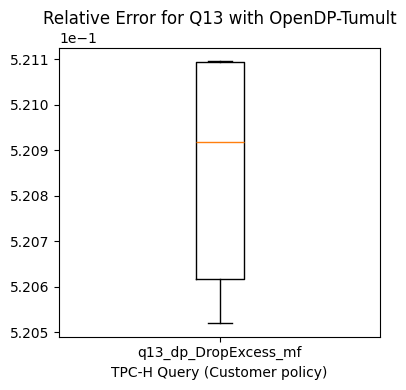

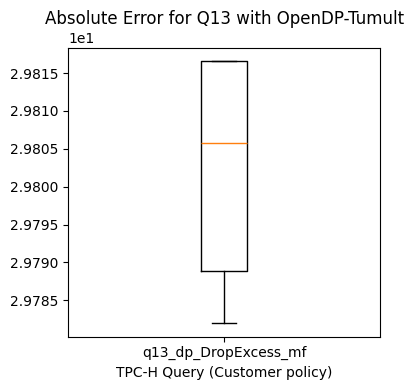

In [15]:
x = q13_calculate_errors(OUTPUT, test_case="q13_dp_DropExcess_mf")
tpch_query_results["q13_dp_DropExcess_mf"] = x

***


In [ ]:
print("opendp eval with TPCH and customer policy Results Summary:")

import matplotlib.pyplot as plt

# Use a stable list of labels (convert to strings) and numeric positions for plotting
queries = list(tpch_query_results.keys())
queries_label = [str(q) for q in queries]
print("Queries evaluated:", queries_label)

avg_qerror = [tpch_query_results[q]["mean_qerror_over_runs"] for q in queries]
print("Average Qerror per query:", avg_qerror)
avg_relerror = [tpch_query_results[q]["mean_relerror_over_runs"] for q in queries]
print("Average RelError per query:", avg_relerror)

positions = list(range(len(queries_label)))

# Absolute error bar plot
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(positions, avg_qerror, color='tab:blue')
ax.set_xticks(positions)
ax.set_xticklabels(queries_label, rotation=45, ha='right')
ax.set_xlabel("TPC-H Query (Customer policy)")
ax.set_ylabel("Average Absolute Error (Qerror)")
ax.set_title("Average Absolute Error Across Runs")
plt.tight_layout()
plt.show()

# Relative error bar plot
fig2, ax2 = plt.subplots(figsize=(4, 4))
ax2.bar(positions, avg_relerror, color='tab:orange')
ax2.set_xticks(positions)
ax2.set_xticklabels(queries_label, rotation=45, ha='right')
ax2.set_xlabel("TPC-H Query (Customer policy)")
ax2.set_ylabel("Average Relative Error")
ax2.set_title("Average Relative Error Across Runs")
plt.tight_layout()
plt.show()

raw_qerror = [tpch_query_results[q]["qerror"] for q in queries]
raw_relerror = [tpch_query_results[q]["relerror"] for q in queries]
import numpy as np
raw_qerror_1d = [np.asarray(x).ravel() for x in raw_qerror]

plt.figure(figsize=(4, 4))
plt.boxplot(
    raw_qerror_1d,
    labels=queries_label,
    showfliers=False
)
plt.xticks(rotation=45, ha='right')
plt.xlabel("TPC-H Query (Customer policy)")
plt.ylabel("Average Absolute Error (Qerror)")
plt.title("qerror Distribution Across Runs")
plt.tight_layout()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

raw_relerror_1d = [np.asarray(x).ravel() for x in raw_relerror]

plt.figure(figsize=(4, 4))
plt.boxplot(
    raw_relerror_1d,
    labels=queries_label,
    showfliers=False
)
plt.xticks(rotation=45, ha='right')
plt.xlabel("TPC-H Query (Customer policy)")
plt.ylabel("Average Relative Error (RelError)")
plt.title("relerror Distribution Across Runs")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.tight_layout()
plt.show()